---
## Imports

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## Simulation function

In [28]:


def run_simulation(A_force, omega, E, I, rho, L, Nx, Nt, A_section, t_end):
    
    #Wave speed
    v = np.sqrt(E/rho)   
    
    A_nd=A_force/(E*A_section)

    omega_nd=omega*(L/v)

    # Spatial grid non dimensional
    x  = np.linspace(0, L, Nx)
    xi=x/L 
    dx = x[1] - x[0]
    dxi= xi[1] - xi[0]

    # Temporal grid non dimensional 
    tau_end = t_end * (v/L)
    dtau = tau_end / Nt

    dt=t_end/Nt

    # Stability check
    CFL = v * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"

    # Stable behaviour
    CFL = dtau / dxi
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"
    print(CFL)

    # limits conditions
    # The beam is clamped on the left side
    def und_left(tau):
        return 0.0
    
    #A force is acting on the right side
    def dund_dxi_right(tau):
        return (A_nd * np.sin(omega_nd * tau))

    # Initial state, the entire beam is at rest
    und=np.zeros(Nx)
    und_dot=np.zeros(Nx)

    #Stocking of every snapshots/every dt
    U=np.zeros((Nt+1,Nx))   #non dimensional u at every moment
    T=np.zeros(Nt+1)
    U[0]=und
    T[0]=0.0

    rows = []

    # Timing loop
    for n in range(Nt):
        tau_n = n * dtau

        # second derivative in space 
        und_xixi= np.zeros(Nx)
        und_xixi[1:-1] = (und[2:] - 2.0*und[1:-1] + und[:-2]) / dxi**2

        # Scheme of Taylor second order 
        und_new     = und    + dtau * und_dot + 0.5 * dtau**2 * und_xixi
        
        # First derivative in time
        und_dot_new = und_dot + dtau * und_xixi

        # 3. Conditions aux limites
        und_new[0]  = und_left(tau_n)
        und_new[-1] = und_new[-2] + dxi * dund_dxi_right(tau_n)

        # 4. Avancement
        und = und_new
        und_dot = und_dot_new

        tau_save = tau_n + dtau 

        #Updating the snapshots
        U[n+1]=und
        T[n+1]=(tau_n+dtau)*(L/v)   #real time

        for j in range (Nx):
            rows.append({
                #Dimensional inputs
                "x"     : xi[j]*L,
                "E":E,
                "rho":rho,
                "L":L,
                "I":I,
                "t"     : tau_save * (L/v),
                "A_force": A_force,
                "omega" : omega_nd,

                #Non dimensional inputs
                "A_nd"  : A_nd,
                "xi"    : xi[j],
                "tau"   : tau_save,

                #Dimensional outputs
                "u"     : L*und[j],

                #Non dimensional outputs
                "u_nd"  : und[j],
            })

    #From ND variables to real displacement

    return pd.DataFrame(rows)

## Test of the run_simulation function

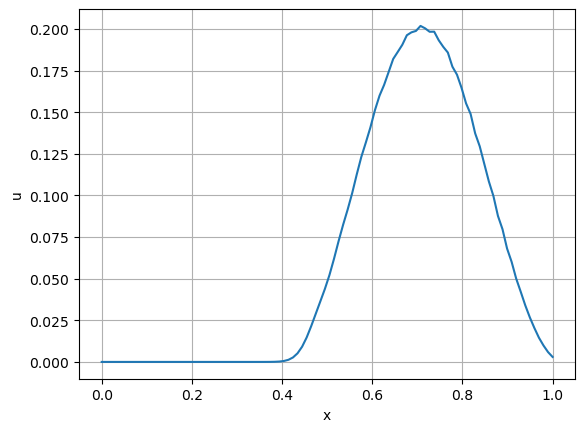

In [ ]:
import matplotlib.pyplot as plt
import numpy as np 

#Parameters
E=1
I=1
rho=1

df = run_simulation(A_force=1.0, omega=10.0, E=E, I=I, rho=rho, L=1,A_section=1, Nx=100, Nt=3000, t_end=3)

t_target=0.6

t_closest = df["t"].iloc[(df["t"]-t_target).abs().argmin()]

snap_chosen=df[df["t"]==t_closest]

plt.plot(snap_chosen["x"],snap_chosen["u"])
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True)
plt.show()

---
## Dataset generation

In [29]:
all_dfs = []

#Parameters selection

N = 5

AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(7, 90, N).round(1).tolist()

Nt  = 3000  

Nx = 100

t_end = 3    
#dt_save=t_end/Nt

E=1
I=1
rho=1
L=1
A_section=1
w=1

#We compute each simulation
for idx, (A, w) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    df_run = run_simulation(A_force=A, omega=w, E=E, I=I, rho=rho, L=L, Nx=Nx, Nt= Nt , A_section=A_section, t_end=t_end)
    all_dfs.append(df_run)

#We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df)

0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
0.09899999999999999
                x  E  rho  L  I      t  A_force  omega   A_nd        xi  \
0        0.000000  1    1  1  1  0.001    0.005    7.0  0.005  0.000000   
1        0.010101  1    1  1  1  0.001    0.005    7.0  0.005  0.010101   
2        0.020202  1    1  1  1  0.001    0.005    7.0  0.005  0.020202   
3        0.030303  1    1  1  1  0.001    0.005    7.0  0.005  0.030303   
4        0.040404  1    1  1  1  0.001    0.005    7.0  0.005  0.040404   
...           ... ..  ... .. ..    ...      ...   

---
## 7. Split train / val / test

In [22]:
rng = np.random.default_rng(seed=42)

combos     = list(product(AMPLITUDES, PULSATIONS))
combos_arr = rng.permutation(combos)

n_sims = len(combos)

n_train = int(0.70 * n_sims)
n_val   = int(0.15 * n_sims)

train_combos = set(map(tuple, combos_arr[:n_train]))
val_combos   = set(map(tuple, combos_arr[n_train:n_train + n_val]))
test_combos  = set(map(tuple, combos_arr[n_train + n_val:]))

def assign_split(row):
    key = (row["A_nd"], row["omega"])
    if key in train_combos: return "train"
    if key in val_combos:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")


Distribution du split :
  train : 5,100,000 lignes  (68.0 %)
  val   :  900,000 lignes  (12.0 %)
  test  : 1,500,000 lignes  (20.0 %)


---
## 8. Normalisation (z-score)


In [23]:
INPUTS  = ["E", "rho", "L", "I", "omega", "A_force","x", "t"]
OUTPUTS = ["u"]

train_mask = df["split"]=="train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

Statistiques de normalisation (calculées sur train) :
              mean           std
E         1.000000      1.000000
rho       1.000000      1.000000
L         1.000000      1.000000
I         1.000000      1.000000
omega    41.182353     30.135603
A_force   0.056588      0.030648
x         0.500000      0.291576
t         1.500500      0.866025
u        -0.294965  82937.133265


---
## Sauvegarde

In [24]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  7,500,000 lignes × 19 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


## Parameter stocking

In [25]:
import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
    "E":E,
    "rho":rho,
    "I":I,
    "A_section":A_section,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


## Visual check

0.05939999999999999
               x  E  rho  L  I       t  A_force  omega  A_nd        xi  \
0       0.000000  1    1  1  1  0.0006      1.0   10.0   1.0  0.000000   
1       0.010101  1    1  1  1  0.0006      1.0   10.0   1.0  0.010101   
2       0.020202  1    1  1  1  0.0006      1.0   10.0   1.0  0.020202   
3       0.030303  1    1  1  1  0.0006      1.0   10.0   1.0  0.030303   
4       0.040404  1    1  1  1  0.0006      1.0   10.0   1.0  0.040404   
...          ... ..  ... .. ..     ...      ...    ...   ...       ...   
499995  0.959596  1    1  1  1  3.0000      1.0   10.0   1.0  0.959596   
499996  0.969697  1    1  1  1  3.0000      1.0   10.0   1.0  0.969697   
499997  0.979798  1    1  1  1  3.0000      1.0   10.0   1.0  0.979798   
499998  0.989899  1    1  1  1  3.0000      1.0   10.0   1.0  0.989899   
499999  1.000000  1    1  1  1  3.0000      1.0   10.0   1.0  1.000000   

           tau         u      u_nd  
0       0.0006  0.000000  0.000000  
1       0.0006  0

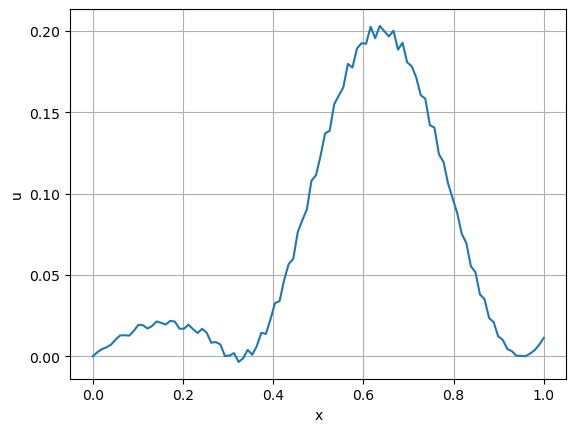

In [ ]:
import matplotlib.pyplot as plt

t_target=1.3

df=run_simulation(A_force=1.0, omega=10, E=1, I=1, rho=1, L=1, Nx=100, Nt=5000, A_section=1, t_end=3)

print(df)

t_closest = df["t"].iloc[(df["t"] - t_target).abs().argmin()]

snap= df[df["t"]==t_closest]

plt.plot(snap["x"],snap["u"])
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True)
plt.show()